In [1]:
from dotenv import load_dotenv

_ = load_dotenv()  # Load environment variables from .env file

In [2]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List
import operator
from langgraph.checkpoint.sqlite import SqliteSaver
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, AIMessage, ChatMessage
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [3]:
class AgentState(TypedDict):
    task: str # Human Input (e.g., "Write an essay about the importance of AI in education.")
    plan: str # Plan generate by the agent (e.g., "1. Research the topic. 2. Create an outline. 3. Write the essay.")
    draft: str # Draft of the essay generated by the agent (e.g., "Artificial Intelligence (AI) has become a transformative force in education...")
    critique: str # Critique of the draft generated by the agent (e.g., "The essay is well-structured, but it could benefit from more specific examples and references to recent studies.")
    content: List[str] # List of documents that the Tavily agent has read/researched and used to generate the essay (e.g., ["Document 1: AI in Education - A Comprehensive Review", "Document 2: The Impact of AI on Learning Outcomes"])
    revision_number: int # The number of revisions the agent has made to the essay (e.g., 1, 2, 3, etc.)
    max_revisions: int # The maximum number of revisions the agent is allowed to make to the essay (e.g., 3, 5, etc.)

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os

# In LangGraph/LangChain, you MUST use the Chat Models (which have .invoke())
# rather than the raw genai.Client().
# LangChain automatically handles all LangSmith tracing for you as long as
# LANGSMITH_TRACING=true is set in your .env!
model = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash", 
    temperature=0.7, 
    max_tokens=2000,
    api_key=os.getenv("GEMINI_API_KEY")
)

In [5]:
PLAN_PROMPT = """You are an expert writer tasked with writing a high level outline of an essay. \
Write such an outline for the user provided topic. Give an outline of the essay along with any relevant notes \
or instructions for the sections.""" # Prompt for the LLM who is going to write a plan for the essay.

In [6]:
WRITER_PROMPT = """You are an essay assistant tasked with writing excellent 5-paragraph essays.\
Generate the best essay possible for the user's request and the initial outline. \
If the user provides critique, respond with a revised version of your previous attempts. \
Utilize all the information below as needed: 

------

{content}""" # This is the one who is writing the essay given all the content that was researched.

In [7]:
REFLECTION_PROMPT = """You are a teacher grading an essay submission. \
Generate critique and recommendations for the user's submission. \
Provide detailed recommendations, including requests for length, depth, style, etc.""" # Prompt that is going to control how we're critiquing the draft of the essay.

In [8]:
RESEARCH_PLAN_PROMPT = """You are a researcher charged with providing information that can \
be used when writing the following essay. Generate a list of search queries that will gather \
any relevant information. Only generate 3 queries max.""" # Prompt for the LLM who is doing the research and the planning step.

In [9]:
RESEARCH_CRITIQUE_PROMPT = """You are a researcher charged with providing information that can \
be used when making any requested revisions (as outlined below). \
Generate a list of search queries that will gather any relevant information. Only generate 3 queries max.""" # The similar as the PLAN_PROMPT, but this is for the revision step. The LLM will be critiquing the essay and then generating a new set of queries to gather more information to improve the essay.

In [10]:
from pydantic import BaseModel, Field

class Queries(BaseModel):
    queries: List[str]

In [11]:
from tavily import TavilyClient
import os

tavily = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

In [12]:
def plan_node(state: AgentState):
  messages = [
    SystemMessage(content=PLAN_PROMPT),
    HumanMessage(content=state["task"])
  ]
  response = model.invoke(messages)
  return {"plan": response.content}

In [13]:
def research_plan_node(state: AgentState):
  queries = model.with_structured_output(Queries).invoke([
    SystemMessage(content=RESEARCH_PLAN_PROMPT),
    HumanMessage(content=state["task"])
  ])
  content = state.get("content", [])
  for q in queries.queries:
    response = tavily.search(query=q, max_results=2)
    for r in response["results"]:
      content.append(r["content"])
  return {"content": content}

In [14]:
def generation_node(state: AgentState):
  content = "\n\n".join(state.get("content", []))
  user_message = HumanMessage(content=f"{state["task"]}\n\nHere is my plan:\n\n{state["plan"]}")
  messages = [
    SystemMessage(content=WRITER_PROMPT.format(content=content)),
    user_message
  ]
  response = model.invoke(messages)
  return {
    "draft": response.content,
    "revision_number": state.get("revision_number", 1) + 1
  }


In [15]:
def reflection_node(state: AgentState):
  messages = [
    SystemMessage(content=REFLECTION_PROMPT),
    HumanMessage(content=state["draft"])
  ]
  response = model.invoke(messages)
  return {"critique": response.content}

In [16]:
def research_critique_node(state: AgentState):
  queries = model.with_structured_output(Queries).invoke([
    SystemMessage(content=RESEARCH_CRITIQUE_PROMPT),
    HumanMessage(content=state["critique"])
  ])
  content = state.get("content", [])
  for q in queries.queries:
    response = tavily.search(query=q, max_results=2)
    for r in response["results"]:
      content.append(r["content"])
  return {"content": content}

In [17]:
def should_continue(state: AgentState):
  if state["revision_number"] > state["max_revisions"]:
    return END
  return "reflect"


In [18]:
builder = StateGraph(AgentState) # Init the Graph

In [19]:
builder.add_node("planner", plan_node)
builder.add_node("generate", generation_node)
builder.add_node("reflect", reflection_node)
builder.add_node("research_plan", research_plan_node)
builder.add_node("research_critique", research_critique_node)

In [20]:
builder.set_entry_point("planner") # Entry point of the graph is the planner node. The agent will start by generating a plan for the essay.

In [21]:
builder.add_conditional_edges(
  "generate",
  should_continue,
  {END: END, "reflect": "reflect"}
) # after the `generate` ndoe, we execute the `should_continue` function and we either going to END or we're going to the `reflect` node. The `reflect` node will generate a critique of the essay and then we will go to the `research_critique` node to gather more information to improve the essay. After that, we will go back to the `generate` node to generate a new draft of the essay. This process will repeat until we reach the maximum number of revisions or the user is satisfied with the essay.

In [22]:
builder.add_edge("planner", "research_plan")
builder.add_edge("research_plan", "generate")
# `generate` node is already covered by the conditional edge above
builder.add_edge("reflect", "research_critique")
builder.add_edge("research_critique", "generate")

In [23]:
graph = builder.compile(checkpointer=memory)

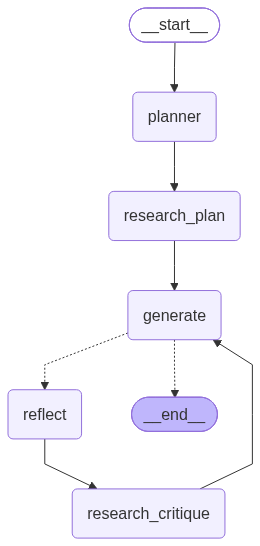

In [24]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
thread = {"configurable": {"thread_id": "1"}}
for s in graph.stream({
  'task': "what is the difference between langchain, langgraph and langsmith?",
  'max_revisions': 3,
  'revision_number': 1,
  'content': [],
}, thread):
  print(s)

d:\repos\essay_writer\venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


ChatGoogleGenerativeAIError: Error calling model 'gemini-3.6-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.6-flash\nPlease retry in 53.22180243s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTi